### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [33]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)
llm.invoke("Hello, world!")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 11, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_eadf229d54', 'id': 'chatcmpl-D3jHVSAJa9WMR1YGwOUhkzTAQ9TuK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c0f31-529c-7233-be8f-03df4af04c45-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 9, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)



In [34]:
from langchain_core.messages import AIMessage, HumanMessage
from pprint import pprint

messages = [AIMessage(content=f"Hello, how can I help you?", name="LLModel")]
messages.append(HumanMessage(content="I want to Lean Coding?", name="Harry"))
messages.append(AIMessage(content="Sure! I can help you with that. Which programming language are you interested in learning?", name="LLModel"))
messages.append(HumanMessage(content="I want to learn Python", name="Harry"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLModel

Hello, how can I help you?
================================ Human Message =================================
Name: Harry

I want to Lean Coding?
================================== Ai Message ==================================
Name: LLModel

Sure! I can help you with that. Which programming language are you interested in learning?
================================ Human Message =================================
Name: Harry

I want to learn Python


## Chat Models
We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [35]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model 
llm_groq = init_chat_model("groq:meta-llama/llama-4-maverick-17b-128e-instruct", temperature=0)
llm_groq.invoke(messages)

AIMessage(content='Python is a great language to learn. It\'s easy to read and write, and has many practical applications. Here\'s a step-by-step guide to get you started:\n\n**Step 1: Install Python**\n\n1. Go to the official Python website: [www.python.org](http://www.python.org)\n2. Click on "Downloads" and select the correct version for your operating system (Windows, macOS, or Linux)\n3. Follow the installation instructions to install Python on your computer\n\n**Step 2: Choose a Text Editor or IDE**\n\n1. A text editor or IDE (Integrated Development Environment) is where you\'ll write your Python code. Some popular choices include:\n\t* PyCharm\n\t* Visual Studio Code (VS Code)\n\t* Sublime Text\n\t* Atom\n\t* Spyder\n2. Choose one that you like, and install it on your computer\n\n**Step 3: Learn the Basics**\n\n1. Start with basic tutorials and online resources, such as:\n\t* Codecademy\'s Python course\n\t* Python.org\'s tutorial\n\t* W3Schools\' Python tutorial\n\t* YouTube tu

In [36]:
result = llm_groq.invoke(messages)
result.response_metadata

{'token_usage': {'completion_tokens': 319,
  'prompt_tokens': 62,
  'total_tokens': 381,
  'completion_time': 0.672448343,
  'completion_tokens_details': None,
  'prompt_time': 0.002787362,
  'prompt_tokens_details': None,
  'queue_time': 0.135293155,
  'total_time': 0.675235705},
 'model_name': 'meta-llama/llama-4-maverick-17b-128e-instruct',
 'system_fingerprint': 'fp_992318f10a',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [37]:
def add (a: int, b: int) -> int:
    """ Add two integers and return the result.
    Args:
        a (int): The first integer.
        b (int): The second integer.
        Returns:
        int: The sum of the two integers.
    """
    return a + b

In [38]:
llm_with_tools = llm.bind_tools([add])
tool_call = llm_with_tools.invoke([HumanMessage(content="What is the sum of 5 and 7?", name="Harry")])
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 5, 'b': 7},
  'id': 'call_1EUy6mIBDBGgdIKfDXx6fOhA',
  'type': 'tool_call'}]

## Using Messages as State 

In [39]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

#### Reducers
Now, we have a minor problem!
* As we discussed, each node will return a new value for our state key messages. But, this new value will override the prior messages value.
* As our graph runs, we want to append messages to our messages state key.
* We can use reducer functions to address this.
* Reducers allow us to specify how state updates are performed.
* If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.
* But, to append messages, we can use the pre-built add_messages reducer.
* This ensures that any messages are appended to the existing list of messages.
* We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [40]:
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

## Reducers with add_messages 

In [41]:
initial_messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Krish"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish')]

In [42]:
ai_message = AIMessage(content="Sure! I can help you with that. Which programming language are you interested in learning?", name="LLMModel")
ai_message

AIMessage(content='Sure! I can help you with that. Which programming language are you interested in learning?', additional_kwargs={}, response_metadata={}, name='LLMModel', tool_calls=[], invalid_tool_calls=[])

In [43]:
### Reducers add_messages is to append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='a80e2e83-8188-4c58-a19a-2faa88faf6f6', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish', id='cc23c747-4224-4169-926e-8d2c22af41f1'),
 AIMessage(content='Sure! I can help you with that. Which programming language are you interested in learning?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='2fbb91f0-29bc-469d-8ac8-45b02d1dddeb', tool_calls=[], invalid_tool_calls=[])]

In [44]:
def llm_tool(state:State):
    return {"messages" :[llm_with_tools.invoke(state["messages"])]}

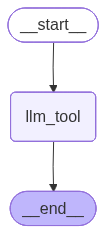

In [45]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("llm_tool",llm_tool)
builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)
graph = builder.compile()
 
display(Image(graph.get_graph().draw_mermaid_png()))

In [47]:
messages = graph.invoke({"messages": "What is the sum of 10 and 15?"})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is the sum of 10 and 15?
================================== Ai Message ==================================
Tool Calls:
  add (call_lXWVmR9Un7bKiXsohX1pp3iH)
 Call ID: call_lXWVmR9Un7bKiXsohX1pp3iH
  Args:
    a: 10
    b: 15


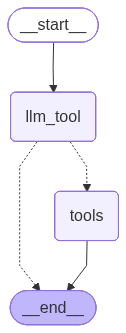

In [50]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

tools = [add]

builder = StateGraph(State)
builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
messages = graph.invoke({"messages": "What is 2 plus 2"})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (call_NWIsklMr6fJTsn437Fej7BuN)
 Call ID: call_NWIsklMr6fJTsn437Fej7BuN
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4


In [54]:
messages = graph.invoke({"messages": "What is python"})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is python
================================== Ai Message ==================================

Python is a high-level, interpreted programming language known for its readability and simplicity. It was created by Guido van Rossum and first released in 1991. Python supports multiple programming paradigms, including procedural, object-oriented, and functional programming. It is widely used for web development, data analysis, artificial intelligence, scientific computing, and more, due to its extensive standard library and the availability of numerous third-party packages. Python's syntax is designed to be clear and straightforward, making it an excellent choice for both beginners and experienced developers.
